# Material Fingerprinting — Coronary Artery Media

**PS2: Biomechanical Fingerprinting — From Tissue Modelling to Synthetic Gel**

**Tissue:** Human Left Anterior Descending (LAD) Coronary Artery — Media Layer  
**Loading Direction:** Circumferential  
**Data Source:** Holzapfel, Sommer, Gasser & Regitnig (2005), *Am J Physiol Heart Circ Physiol*, 289: H2048–H2058  
**Model:** Demiray Hyperelastic Model  

---

## Background

The Demiray strain energy function is:

$$\Psi = \frac{a}{2b} \left[ \exp\left(b(I_1 - 3)\right) - 1 \right]$$

For incompressible uniaxial tension, the Cauchy stress is:

$$\sigma = a(\lambda^2 - \lambda^{-1}) \cdot \exp\left(b(I_1 - 3)\right)$$

where $I_1 = \lambda^2 + 2/\lambda$ is the first invariant of the right Cauchy-Green tensor.

**Material constants to find:**
- $a$ (kPa) — stress-like parameter controlling baseline stiffness
- $b$ (dimensionless) — controls rate of exponential stiffening

## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

print('All libraries imported successfully')

All libraries imported successfully


## Step 2 — Load Experimental Data

In [7]:
data = pd.read_csv('C:/Users/Krutarth0911/Downloads/SaviDataset.csv')
lam = data.iloc[:, 0].values
sigma = data.iloc[:, 1].values
print(f'Loaded {len(lam)} data points')
print(f'Stretch range: {lam.min():.3f} to {lam.max():.3f}')
print(f'Stress range:  {sigma.min():.2f} to {sigma.max():.2f} kPa')
print(data.head(10))

Loaded 43 data points
Stretch range: 1.000 to 1.328
Stress range:  1.36 to 132.18 kPa
    stretch    stress
0  1.000000  1.358025
1  1.018072  1.810700
2  1.031627  2.716049
3  1.046687  3.847737
4  1.056476  4.526749
5  1.067771  5.432099
6  1.079819  6.790123
7  1.091867  7.695473
8  1.102410  8.600823
9  1.111822  9.279835


## Step 3 — Plot Raw Experimental Data

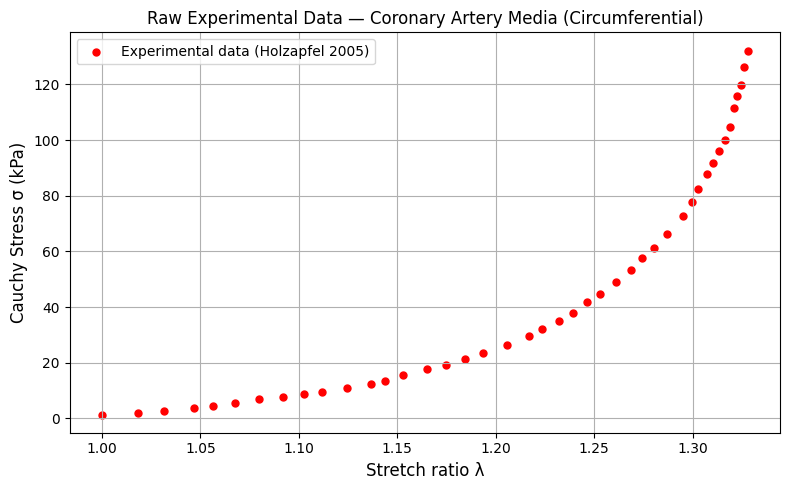

Note the J-shaped curve — flat toe region then exponential rise


In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(lam, sigma, color='red', s=25, label='Experimental data (Holzapfel 2005)')
plt.xlabel('Stretch ratio λ', fontsize=12)
plt.ylabel('Cauchy Stress σ (kPa)', fontsize=12)
plt.title('Raw Experimental Data — Coronary Artery Media (Circumferential)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('raw_data.png', dpi=150)
plt.show()
print('Note the J-shaped curve — flat toe region then exponential rise')

## Step 4 — Define Demiray Model

In [9]:
def demiray_stress(lam, a, b):
    """
    Demiray hyperelastic model uniaxial Cauchy stress.
    Parameters:
        lam : stretch ratio
        a   : stress-like constant (kPa)
        b   : dimensionless constant
    Returns:
        sigma : Cauchy stress (kPa)
    """
    I1 = lam**2 + 2.0/lam
    return a * (lam**2 - 1.0/lam) * np.exp(b * (I1 - 3.0))

print('Demiray model defined: sigma = a*(lambda^2 - 1/lambda)*exp(b*(I1-3))')

Demiray model defined: sigma = a*(lambda^2 - 1/lambda)*exp(b*(I1-3))


## Step 5 — Fit Model to Data (Material Fingerprinting)

In [10]:
popt, pcov = curve_fit(demiray_stress, lam, sigma, p0=[2.0, 3.0], maxfev=10000)
a_fit, b_fit = popt
perr = np.sqrt(np.diag(pcov))

print('=' * 40)
print('MATERIAL FINGERPRINT')
print('=' * 40)
print(f'  a = {a_fit:.4f} +/- {perr[0]:.4f} kPa')
print(f'  b = {b_fit:.4f} +/- {perr[1]:.4f}')
print('=' * 40)

MATERIAL FINGERPRINT
  a = 17.1512 +/- 0.8815 kPa
  b = 7.2591 +/- 0.2121


## Step 6 — Validate the Fit

In [11]:
sigma_pred = demiray_stress(lam, a_fit, b_fit)
ss_res = np.sum((sigma - sigma_pred)**2)
ss_tot = np.sum((sigma - np.mean(sigma))**2)
r2 = 1 - ss_res / ss_tot
rmse = np.sqrt(np.mean((sigma - sigma_pred)**2))

print(f'R2   = {r2:.4f}')
print(f'RMSE = {rmse:.4f} kPa')
if r2 > 0.99:
    print('Excellent fit (R2 > 0.99)')

R2   = 0.9943
RMSE = 3.0304 kPa
Excellent fit (R2 > 0.99)


## Step 7 — Validation Plot

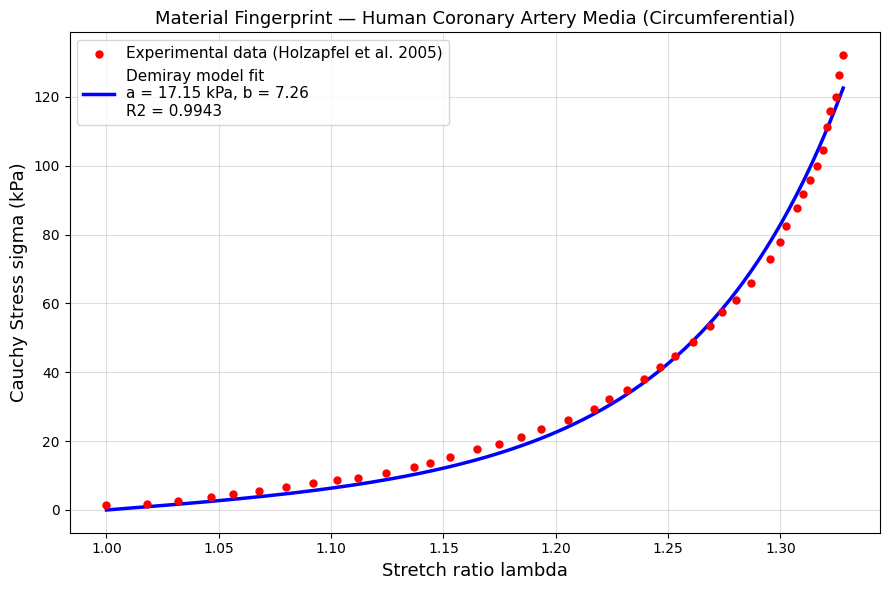

Plot saved as material_fingerprint.png


In [12]:
lam_smooth = np.linspace(lam.min(), lam.max(), 300)
sigma_smooth = demiray_stress(lam_smooth, a_fit, b_fit)

plt.figure(figsize=(9, 6))
plt.scatter(lam, sigma, color='red', s=25, zorder=5, label='Experimental data (Holzapfel et al. 2005)')
plt.plot(lam_smooth, sigma_smooth, 'b-', linewidth=2.5,
         label=f'Demiray model fit\na = {a_fit:.2f} kPa, b = {b_fit:.2f}\nR2 = {r2:.4f}')
plt.xlabel('Stretch ratio lambda', fontsize=13)
plt.ylabel('Cauchy Stress sigma (kPa)', fontsize=13)
plt.title('Material Fingerprint — Human Coronary Artery Media (Circumferential)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('material_fingerprint.png', dpi=150)
plt.show()
print('Plot saved as material_fingerprint.png')

## Summary

| Parameter | Value | Units |
|-----------|-------|-------|
| a | 17.15 | kPa |
| b | 7.26 | dimensionless |
| R² | 0.9943 | dimensionless |
| Tissue | Coronary artery media | — |
| Direction | Circumferential | — |
| Model | Demiray | — |

These two constants are the **material fingerprint** of the human coronary artery media. They will be used as the target mechanical response that the LAMMPS polymer gel simulation must reproduce in Phase 3.